# Local Search Experiments (Campaign-Time Calibration)

All experiments use campaign-time calibration with $\eta$ parameter for energy scaling.
The local search framework consists of:
- **4 initial tour heuristics** (R1–R4)
- **4 neighborhood operators** (add, replace, swap, 2-opt)
- **Metaheuristics:** Simulated Annealing, Iterated Local Search (ILS), Hill Climbing, Tilted Runs

In [1]:
import sys
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure repo root is on sys.path regardless of kernel cwd
_notebook_dir = os.path.dirname(os.path.abspath("__file__"))
_repo_root = os.path.abspath(os.path.join(_notebook_dir, "..")) if os.path.basename(_notebook_dir) == "experiments" else _notebook_dir
if _repo_root not in sys.path:
    sys.path.insert(0, _repo_root)
os.chdir(_repo_root)

from uav_routing.environment import Environment
from uav_routing.environment.calibration import calibrate, calibration_info
from uav_routing.environment.graph import Graph, directed_cycle, nearest_neighbor_tour
from uav_routing.environment.drone import Drone
from uav_routing.local_search.state import State
from uav_routing.local_search.optimization import Optimizer
from uav_routing.local_search.proposal import universal_proposal, random_flip_with_tabu
from uav_routing.local_search.accept import always_accept
from uav_routing.local_search.initial_solution import (
    build_R1, build_R2, build_R3, build_R4, INITIAL_TOURS
)
from uav_routing.solver.socp import Solver

# Dataset paths (relative to repo root)
datasets = {
    "C101 (50)":  "datasets/data/50_c101.txt",
    "R101 (50)":  "datasets/data/50_r101.txt",
    "RC101 (100)": "datasets/data/rc101.txt",
    "R101 (100)": "datasets/data/r101.txt",
    "C101 (100)": "datasets/data/c101.txt",
}

SEED = 42
SORTIE_TIME = 3.0

def make_instance(path, slope='random', graph_seed=1, eta=1.0):
    """Create a campaign-calibrated instance."""
    graph = Graph(path=path, slope=slope, seed=graph_seed)
    uav = Drone(base=graph.graph['base'])
    calib = calibrate(
        graph=graph,
        tour_length=len(graph.nodes) // 2,
        drone=uav,
        drone_sortie_time=SORTIE_TIME,
        calibration_method="campaign",
    )
    return Environment(calib, uav, eta=eta), graph, uav

print(f"Working directory: {os.getcwd()}")

Working directory: /Users/kirtisoglu/Documents/GitHub/UAV-Routing


---
## 1. Initial Tour Comparison

Evaluate all 4 initial tour heuristics (R1–R4) on the same instance.
Each tour is evaluated by solving the SOCP subproblem for optimal speeds.

**Settings:** R101 (50), $\eta = 1$, random slopes, campaign-time calibration.

**Purpose:** Compare the quality and feasibility of initial solutions before local search.
- R1/R2/R3 are geometry-based — fast but information-unaware.
- R4 is short and random — provides diversity for multi-start.
- R5 is information-and-energy-aware — expected to produce the best starting objective.
- All heuristics verify feasibility at each step via the SOCP subproblem.

In [2]:
all_init_rows = []
for ds_name, ds_path in datasets.items():
    instance, graph, uav = make_instance(ds_path)
    print(f"\n{'='*60}")
    print(f"  {ds_name}")

    for name, builder in INITIAL_TOURS.items():
        t0 = time.time()
        tour_graph = builder(instance)
        build_time = time.time() - t0
        solver = Solver(tour_graph, instance)
        td = solver.get_tour_data()
        all_init_rows.append({
            "Instance": ds_name,
            "Heuristic": name,
            "Tour length": len(tour_graph.nodes) - 1,
            "Feasible": td.feasible,
            "Objective": round(td.objective, 2) if td.feasible else None,
            "Energy (J)": round(td.total_energy, 1) if td.feasible else None,
            "Build time (s)": round(build_time, 3),
        })

df_init = pd.DataFrame(all_init_rows)
df_init


  C101 (50)

  R101 (50)

  RC101 (100)

  R101 (100)

  C101 (100)


,Instance,Heuristic,Tour length,Feasible,Objective,Energy (J),Build time (s)
0,C101 (50),R1 (earliest),4,True,-1798.97,145204254.2,0.031
1,C101 (50),R2 (rand+earliest),4,True,1439.20,164277673.6,0.027
2,C101 (50),R3 (random),4,True,2732.71,166752084.1,0.006
3,C101 (50),R4 (info-eff),12,True,3243.31,170051377.7,0.329
4,R101 (50),R1 (earliest),4,True,13253.98,157135878.1,0.007
5,R101 (50),R2 (rand+earliest),4,True,-3569.28,170025838.3,0.032
6,R101 (50),R3 (random),3,True,26.00,169359954.3,0.014
7,R101 (50),R4 (info-eff),4,True,21328.22,155919131.5,0.082
8,RC101 (100),R1 (earliest),4,True,-11105.21,158365145.8,0.003
9,RC101 (100),R2 (rand+earliest),4,True,34216.93,168723673.3,0.056


### 1b. Initial Tour Comparison Across Datasets

Run all heuristics on all datasets to check robustness.

**Purpose:** Verify that initial tour quality is consistent across instance types (clustered, random, mixed). R5 should consistently rank near the top. Infeasibility patterns reveal which heuristics are brittle on which instance geometries.

In [3]:
cross_rows = []
for ds_name, path in datasets.items():
    instance, graph, uav = make_instance(path)
    for h_name, builder in INITIAL_TOURS.items():
        tour_graph = builder(instance)
        solver = Solver(tour_graph, instance)
        td = solver.get_tour_data()
        cross_rows.append({
            "Instance": ds_name,
            "Heuristic": h_name,
            "Tour length": len(tour_graph.nodes) - 1,
            "Feasible": td.feasible,
            "Objective": round(td.objective, 2) if td.feasible else None,
        })

df_cross = pd.DataFrame(cross_rows)
# Pivot for readability
df_pivot = df_cross.pivot_table(index='Instance', columns='Heuristic',
                                 values='Objective', aggfunc='first')
df_pivot

Heuristic,R1 (earliest),R2 (rand+earliest),R3 (random),R4 (info-eff)
Instance,,,,
C101 (100),-103.30,4.68,750.33,9483.18
C101 (50),-1798.97,1439.20,2732.71,3243.31
R101 (100),-1290.03,6839.25,-7385.59,105074.81
R101 (50),13253.98,-3569.28,26.00,21328.22
RC101 (100),-11105.21,34216.93,10261.67,91649.92


---
## 2. ILS: Effect of Initial Tour on Final Solution

Run ILS from each initial tour and compare final objectives.
This tests whether a better starting point leads to a better final solution,
or whether ILS is robust to initialization.

**Settings:** R101 (50), $\eta = 1$, random slopes, ILS with 200 steps, $t_\text{improve} = 30$, $k_\text{remove} = 2$, tabu tenure = 10.

**Purpose:** Determine whether initial tour quality matters for ILS.
- If all final objectives converge to similar values → ILS is robust, initial tour mainly affects speed.
- If R5 consistently leads to better finals → initial tour quality propagates through search.
- R4 (short random) tests whether ILS can build up a good tour from a minimal start.
- Improvement (%) quantifies how much local search adds beyond the construction heuristic.

In [4]:
ILS_STEPS = 10000
ILS_T_IMPROVE = 50
ILS_K_REMOVE = 2
ILS_TABU_TENURE = 5

ils_rows = []
for ds_name, path in datasets.items():
    instance, graph, uav = make_instance(path)
    for name, builder in INITIAL_TOURS.items():
        tour_graph = builder(instance)
        solver = Solver(tour_graph, instance)
        if solver.solution is None:
            ils_rows.append({"Instance": ds_name, "Initial tour": name, "Init obj": None,
                             "Final obj": None, "Improvement (%)": None,
                             "Time (s)": None, "Final tour len": None})
            continue

        init_obj = solver.get_tour_data().objective
        state = State.initial_state(instance, tour_graph)
        optimizer = Optimizer(
            proposal=lambda s: universal_proposal(s),
            initial_state=state,
            maximize=True
        )
        t0 = time.time()
        for s in optimizer.run_ils(
            total_steps=ILS_STEPS,
            t_improve=ILS_T_IMPROVE,
            k_remove=ILS_K_REMOVE,
            tabu_tenure=ILS_TABU_TENURE,
        ):
            pass
        elapsed = time.time() - t0

        final_obj = optimizer._best_score
        improvement = ((final_obj - init_obj) / abs(init_obj) * 100) if init_obj else None
        ils_rows.append({
            "Instance": ds_name,
            "Initial tour": name,
            "Init obj": round(init_obj, 2),
            "Final obj": round(final_obj, 2) if final_obj else None,
            "Improvement (%)": round(improvement, 1) if improvement else None,
            "Time (s)": round(elapsed, 1),
            "Final tour len": len(list(optimizer._best_state.tour.nodes)) - 1 if optimizer._best_state else None,
        })

df_ils_init = pd.DataFrame(ils_rows)
df_ils_init

,Instance,Initial tour,Init obj,Final obj,Improvement (%),Time (s),Final tour len
0,C101 (50),R1 (earliest),-1798.97,14548.73,908.7,15.6,31
1,C101 (50),R2 (rand+earliest),1439.20,14647.50,917.8,16.8,33
2,C101 (50),R3 (random),2732.71,14668.34,436.8,15.7,33
3,C101 (50),R4 (info-eff),3243.31,14555.30,348.8,18.1,34
4,R101 (50),R1 (earliest),13253.98,136153.47,927.3,4.7,8
5,R101 (50),R2 (rand+earliest),-3569.28,136153.47,3914.6,4.7,8
6,R101 (50),R3 (random),26.00,136153.47,523567.2,4.8,8
7,R101 (50),R4 (info-eff),21328.22,144232.37,576.3,4.5,6
8,RC101 (100),R1 (earliest),-11105.21,198064.48,1883.5,6.7,8
9,RC101 (100),R2 (rand+earliest),34216.93,207246.88,505.7,7.6,10


---
## 3. Metaheuristic Comparison

Compare ILS, Simulated Annealing, Hill Climbing, and Tilted Runs
on the same instance and initial tour, with the same step budget.

**Settings:** R101 (50), $\eta = 1$, random slopes, 300 steps, R1 initial tour.

**Purpose:** Identify which metaheuristic is best suited for this problem.
- **Hill Climbing** is the baseline — fast but trapped in local optima.
- **Tilted run** accepts worse solutions with probability $p$ — mild diversification.
- **SA** uses temperature-based acceptance — more systematic exploration.
- **ILS** combines local search with perturbation + tabu — expected to be most effective because the perturbation mechanism removes multiple nodes and the tabu list prevents cycling.
- If ILS and SA converge to similar objectives, the simpler method is preferred.

In [5]:
NUM_STEPS = 10000
SA_BETA_MAGNITUDE = 50

all_methods = {}  # keyed by dataset name

for ds_name, ds_path in datasets.items():
    print(f"\n{'='*60}")
    print(f"  {ds_name}")
    print(f"{'='*60}")
    random.seed(SEED)
    instance, graph, uav = make_instance(ds_path)
    init_tour = build_R4(instance)

    methods = {}

    # --- ILS ---
    random.seed(SEED)
    state = State.initial_state(instance, init_tour)
    opt = Optimizer(proposal=lambda s: universal_proposal(s), initial_state=state, maximize=True)
    t0 = time.time()
    history_ils = []
    for s in opt.run_ils(total_steps=NUM_STEPS, t_improve=30, k_remove=2, tabu_tenure=10):
        history_ils.append(opt._best_score)
    methods["ILS"] = {"obj": opt._best_score, "time": time.time() - t0, "history": history_ils}

    # --- Simulated Annealing (linear-cycle) ---
    random.seed(SEED)
    state = State.initial_state(instance, init_tour)
    opt = Optimizer(proposal=lambda s: universal_proposal(s), initial_state=state, maximize=True)
    beta_fn = Optimizer.linearcycle_beta_function(NUM_STEPS // 4, NUM_STEPS // 4, NUM_STEPS // 2)
    t0 = time.time()
    history_sa = []
    for s in opt.simulated_annealing(num_steps=NUM_STEPS, beta_function=beta_fn,
                                      beta_magnitude=SA_BETA_MAGNITUDE):
        history_sa.append(opt._best_score)
    methods["SA (linear)"] = {"obj": opt._best_score, "time": time.time() - t0, "history": history_sa}

    # --- Hill Climbing ---
    random.seed(SEED)
    state = State.initial_state(instance, init_tour)
    opt = Optimizer(proposal=lambda s: universal_proposal(s), initial_state=state, maximize=True)
    t0 = time.time()
    history_hc = []
    for s in opt.ascent_run(num_steps=NUM_STEPS, accept=always_accept):
        history_hc.append(opt._best_score)
    methods["Hill Climb"] = {"obj": opt._best_score, "time": time.time() - t0, "history": history_hc}

    # --- Tilted Run (p=0.1) ---
    random.seed(SEED)
    state = State.initial_state(instance, init_tour)
    opt = Optimizer(proposal=lambda s: universal_proposal(s), initial_state=state, maximize=True)
    t0 = time.time()
    history_tilt = []
    for s in opt.tilted_run(num_steps=NUM_STEPS, p=0.1):
        history_tilt.append(opt._best_score)
    methods["Tilted (p=0.1)"] = {"obj": opt._best_score, "time": time.time() - t0, "history": history_tilt}

    all_methods[ds_name] = methods

    meta_rows = [{"Method": k, "Best obj": round(v["obj"], 2) if v["obj"] else None,
                  "Time (s)": round(v["time"], 1)} for k, v in methods.items()]
    print(pd.DataFrame(meta_rows).to_string(index=False))


  C101 (50)
        Method  Best obj  Time (s)
           ILS  14640.66      17.9
   SA (linear)  11549.43       5.9
    Hill Climb   4461.86       3.1
Tilted (p=0.1)   9129.16       7.9

  R101 (50)
        Method  Best obj  Time (s)
           ILS 123734.41       4.8
   SA (linear) 144232.37       3.8
    Hill Climb  74991.00       2.6
Tilted (p=0.1) 114687.69       3.5

  RC101 (100)
        Method  Best obj  Time (s)
           ILS 222043.77       6.8
   SA (linear) 220880.85       4.4
    Hill Climb 108766.93       3.0
Tilted (p=0.1) 165232.78       4.3

  R101 (100)
        Method  Best obj  Time (s)
           ILS 282443.22       6.2
   SA (linear) 252776.44       4.0
    Hill Climb 107285.54       2.7
Tilted (p=0.1) 165393.26       4.0

  C101 (100)
        Method  Best obj  Time (s)
           ILS  22815.06      18.8
   SA (linear)  14897.22       6.0
    Hill Climb   9595.63       3.1
Tilted (p=0.1)  11876.10       7.4


### 3b. Convergence Curves

Four curves (ILS, SA, Hill Climb, Tilted) showing best objective vs iteration.

**Purpose:** Visualize convergence speed and final quality. Hill climbing should plateau earliest. SA and tilted runs may show staircase patterns. ILS should show jumps after perturbation phases.

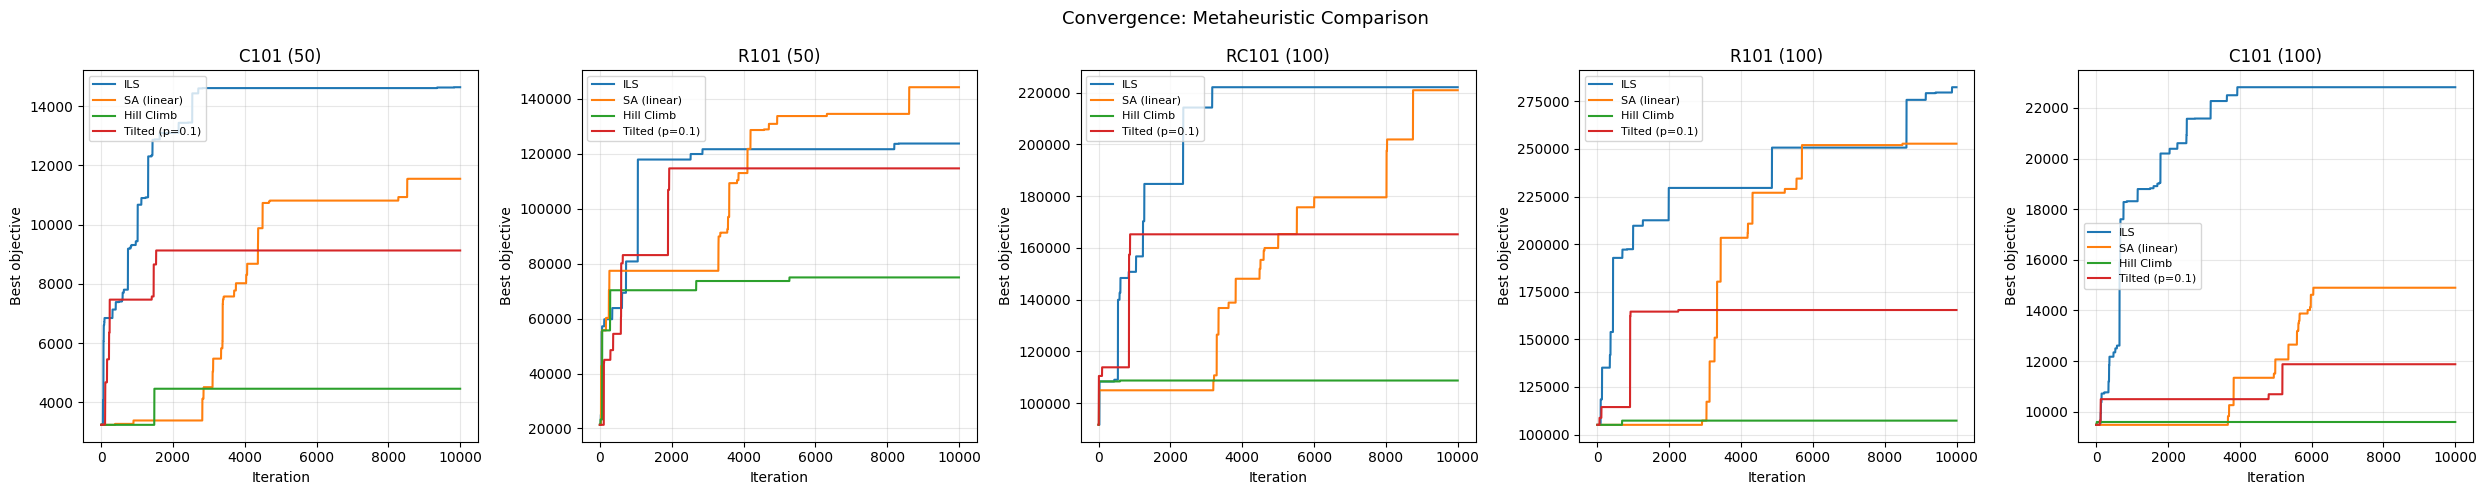

In [6]:
n_datasets = len(all_methods)
fig, axes = plt.subplots(1, n_datasets, figsize=(5 * n_datasets, 5), squeeze=False)
axes = axes[0]

for idx, (ds_name, methods) in enumerate(all_methods.items()):
    ax = axes[idx]
    for name, data in methods.items():
        ax.plot(data["history"], label=name)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Best objective")
    ax.set_title(ds_name)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("Convergence: Metaheuristic Comparison", fontsize=13)
fig.tight_layout()

### 3c. ILS Perturbation Analysis

Track the objective value at each ILS iteration, marking perturbation events.
This shows how the search escapes local optima through the shake mechanism.

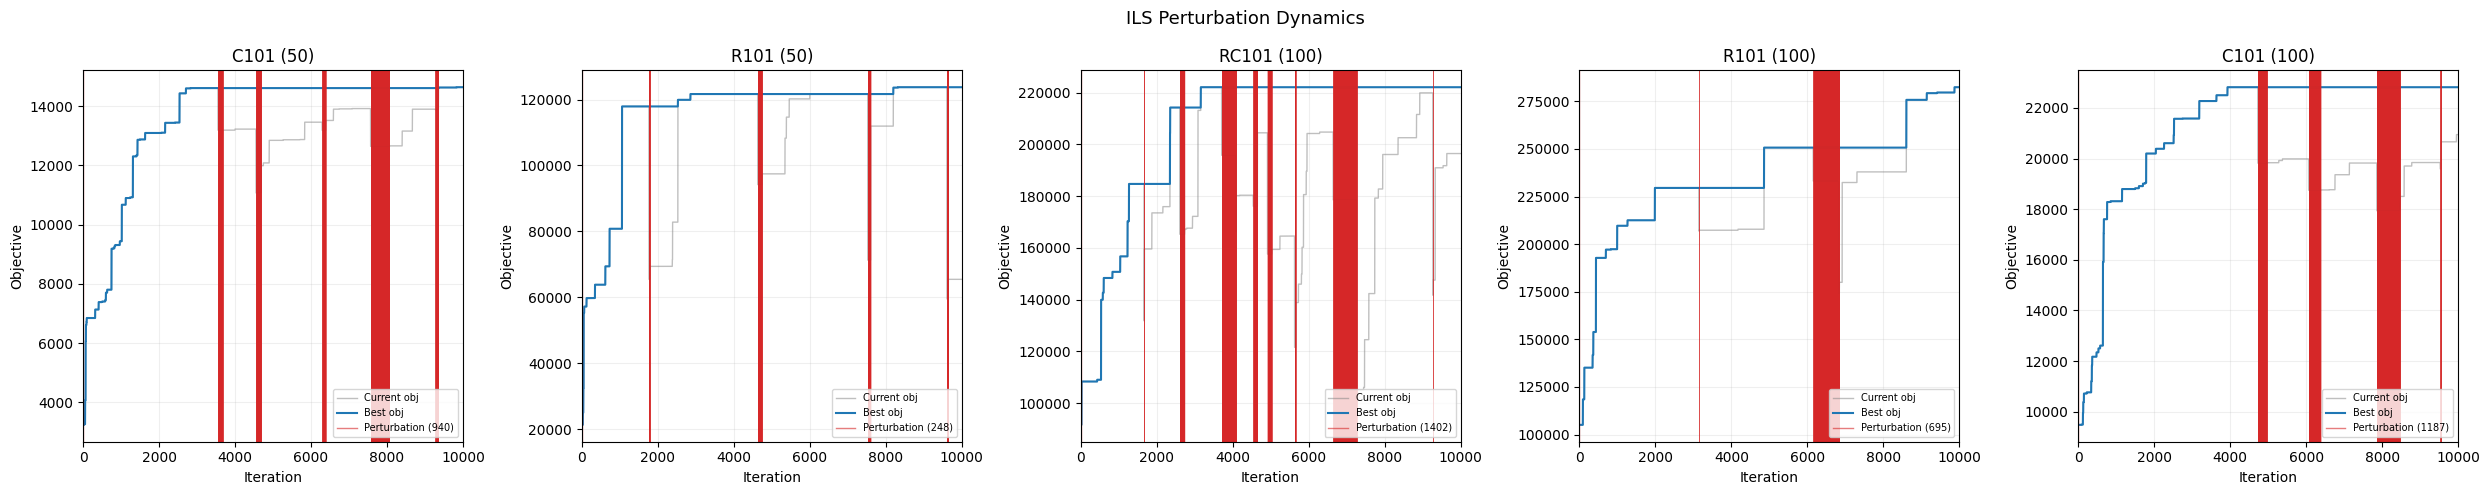

In [7]:
NUM_STEPS_PERTURB = 10000

n_datasets = len(datasets)
fig, axes = plt.subplots(1, n_datasets, figsize=(5 * n_datasets, 5), squeeze=False)
axes = axes[0]

for idx, (ds_name, ds_path) in enumerate(datasets.items()):
    random.seed(SEED)
    instance, graph, uav = make_instance(ds_path)
    init_tour = build_R4(instance)

    state = State.initial_state(instance, init_tour)
    opt = Optimizer(proposal=lambda s: universal_proposal(s), initial_state=state, maximize=True)

    current_objs = []
    best_objs = []
    perturb_iters = []

    for i, s in enumerate(opt.run_ils(total_steps=NUM_STEPS_PERTURB, t_improve=30, k_remove=2, tabu_tenure=10)):
        current_objs.append(s.value if s.solver and s.solver.solution else None)
        best_objs.append(opt._best_score)
        if getattr(s, 'is_perturbation', False):
            perturb_iters.append(i)

    ax = axes[idx]
    valid = [(i, v) for i, v in enumerate(current_objs) if v is not None]
    if valid:
        ax.plot([x[0] for x in valid], [x[1] for x in valid],
                color='gray', linewidth=1.0, alpha=0.5, label='Current obj')
    ax.plot(best_objs, color='tab:blue', linewidth=1.5, label='Best obj')

    for pi in perturb_iters:
        ax.axvline(x=pi, color='tab:red', alpha=0.3, linewidth=0.5)
    if perturb_iters:
        ax.axvline(x=-1, color='tab:red', alpha=0.6, linewidth=1,
                   label=f'Perturbation ({len(perturb_iters)})')

    ax.set_xlabel("Iteration")
    ax.set_ylabel("Objective")
    ax.set_title(ds_name)
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(True, alpha=0.2)
    ax.set_xlim(0, NUM_STEPS_PERTURB)

fig.suptitle("ILS Perturbation Dynamics", fontsize=13)
fig.tight_layout()

---
## 4. ILS Hyperparameter Tuning

Sweep key ILS parameters: perturbation size ($k_\text{remove}$), stagnation threshold ($t_\text{improve}$), and tabu tenure.

**Settings:** R101 (50), $\eta = 1$, random slopes, 300 ILS steps, R1 initial tour.

**Grid:** $k_\text{remove} \in \{1, 2, 3, 4\}$, $t_\text{improve} \in \{15, 30, 50\}$, tabu tenure $\in \{5, 10, 20\}$ (36 combinations).

**Purpose:** Identify the best hyperparameter combination for ILS.
- **$k_\text{remove}$:** Too small → weak perturbation, stuck in basin. Too large → destroys good structure.
- **$t_\text{improve}$:** Too small → perturbations too frequent, search is erratic. Too large → wastes steps in stagnation.
- **Tabu tenure:** Too short → removed nodes re-enter immediately, perturbation is nullified. Too long → search space artificially restricted.
- Analogous to Tural et al.'s ILS hyperparameter tuning (Table 3 in their paper).

In [8]:
ILS_TOTAL = 5000

hp_rows = []
for ds_name, ds_path in datasets.items():
    print(f"\n{'='*60}")
    print(f"  {ds_name}")
    instance, graph, uav = make_instance(ds_path)
    init_tour = build_R4(instance)

    for k_rem in [1, 2, 3, 4]:
        for t_imp in [15, 30, 50]:
            for tenure in [5, 10, 20]:
                random.seed(SEED)
                state = State.initial_state(instance, init_tour)
                opt = Optimizer(proposal=lambda s: universal_proposal(s),
                                initial_state=state, maximize=True)
                t0 = time.time()
                for s in opt.run_ils(total_steps=ILS_TOTAL, t_improve=t_imp,
                                     k_remove=k_rem, tabu_tenure=tenure):
                    pass
                elapsed = time.time() - t0
                hp_rows.append({
                    "Instance": ds_name,
                    "k_remove": k_rem,
                    "t_improve": t_imp,
                    "tabu_tenure": tenure,
                    "Best obj": round(opt._best_score, 2) if opt._best_score else None,
                    "Time (s)": round(elapsed, 1),
                })

df_hp = pd.DataFrame(hp_rows)
# Show top 5 per dataset
for ds_name in datasets:
    print(f"\n--- {ds_name} top 5 ---")
    print(df_hp[df_hp["Instance"] == ds_name].sort_values("Best obj", ascending=False).head(5).to_string(index=False))


  C101 (50)

  R101 (50)

  RC101 (100)

  R101 (100)

  C101 (100)

--- C101 (50) top 5 ---
 Instance  k_remove  t_improve  tabu_tenure  Best obj  Time (s)
C101 (50)         4         50           20  14657.44       8.9
C101 (50)         2         50            5  14657.44       8.7
C101 (50)         4         50           10  14657.44       8.8
C101 (50)         3         50           10  14657.44       8.7
C101 (50)         1         50            5  14657.44       8.7

--- R101 (50) top 5 ---
 Instance  k_remove  t_improve  tabu_tenure  Best obj  Time (s)
R101 (50)         4         15            5 144232.37       2.1
R101 (50)         4         15           10 144232.37       2.2
R101 (50)         2         50            5 134524.09       2.3
R101 (50)         4         50           10 134524.09       2.5
R101 (50)         4         50            5 134524.09       2.3

--- RC101 (100) top 5 ---
   Instance  k_remove  t_improve  tabu_tenure  Best obj  Time (s)
RC101 (100)         

---
## 5. SA Temperature Schedule Comparison

Compare different $\beta$-function shapes for simulated annealing.

**Settings:** R101 (50), $\eta = 1$, random slopes, 300 SA steps, R1 initial tour.

**Purpose:** Determine which cooling schedule works best.
- **Jump-cycle:** Alternates hot/cold phases abruptly — good for escaping local optima in bursts.
- **Linear-cycle:** Smooth cooldown then cold phase — more gradual.
- **Logit-cycle:** S-shaped transition — spends more time at intermediate temperatures.

In [9]:
SA_STEPS = 10000
SA_BETA_MAG = 50

sa_all_results = {}

for ds_name, ds_path in datasets.items():
    print(f"\n{'='*60}")
    print(f"  {ds_name}")
    instance, graph, uav = make_instance(ds_path)
    init_tour = build_R4(instance)

    schedules = {
        "jump-cycle": Optimizer.jumpcycle_beta_function(SA_STEPS // 2, SA_STEPS // 2),
        "linear-cycle": Optimizer.linearcycle_beta_function(SA_STEPS // 4, SA_STEPS // 4, SA_STEPS // 2),
        "logit-cycle": Optimizer.logitcycle_beta_function(SA_STEPS // 4, SA_STEPS // 4, SA_STEPS // 2),
    }

    ds_results = {}
    for sched_name, beta_fn in schedules.items():
        random.seed(SEED)
        state = State.initial_state(instance, init_tour)
        opt = Optimizer(proposal=lambda s: universal_proposal(s),
                        initial_state=state, maximize=True)
        t0 = time.time()
        history = []
        for s in opt.simulated_annealing(num_steps=SA_STEPS, beta_function=beta_fn,
                                          beta_magnitude=SA_BETA_MAG):
            history.append(opt._best_score)
        elapsed = time.time() - t0
        ds_results[sched_name] = {"obj": opt._best_score, "time": elapsed, "history": history}

    sa_all_results[ds_name] = ds_results
    sa_rows = [{"Schedule": k, "Best obj": round(v["obj"], 2) if v["obj"] else None,
                "Time (s)": round(v["time"], 1)} for k, v in ds_results.items()]
    print(pd.DataFrame(sa_rows).to_string(index=False))


  C101 (50)
    Schedule  Best obj  Time (s)
  jump-cycle  11232.57       5.6
linear-cycle  11549.43       6.3
 logit-cycle  11763.00       6.4

  R101 (50)
    Schedule  Best obj  Time (s)
  jump-cycle 144232.37       3.5
linear-cycle 144232.37       4.0
 logit-cycle 144232.37       3.9

  RC101 (100)
    Schedule  Best obj  Time (s)
  jump-cycle 220880.85       4.6
linear-cycle 220880.85       4.6
 logit-cycle 198293.18       4.2

  R101 (100)
    Schedule  Best obj  Time (s)
  jump-cycle 245312.12       3.8
linear-cycle 252776.44       4.1
 logit-cycle 249603.63       4.3

  C101 (100)
    Schedule  Best obj  Time (s)
  jump-cycle  15859.46       5.4
linear-cycle  14897.22       6.2
 logit-cycle  14764.53       6.0


---
## 6. Scalability: ILS vs Exact

Compare ILS solution quality against exact solver (from exact.ipynb) on all datasets.
ILS runs with fixed step budget; exact runs with 600s time limit.

**Settings:** $\eta = 1$, random slopes, campaign-time calibration. Exact: 600s time limit. ILS: 500 steps, R1 initial tour.

**Purpose:** The central comparison table.
- On 50-node instances: exact solver should find optimal; ILS gap quantifies heuristic quality.
- On 100-node instances: exact solver hits time limit with large gap; ILS may actually find better incumbents faster.
- ILS time should be much less than exact time on large instances.
- This is analogous to Tural et al.'s Table 5 (GI vs ILS vs Exact comparison).

In [10]:
from uav_routing.solver.exact import solve_model_gurobi
import gurobipy as gp

ILS_STEPS_SCALE = 10000
EXACT_TIME_LIMIT = 600

scale_rows = []
with gp.Env(empty=True) as env:
    env.setParam('OutputFlag', 0)
    env.start()

    for ds_name, path in datasets.items():
        instance, graph, uav = make_instance(path)
        n = len(graph.nodes)

        # --- Exact ---
        res_exact = solve_model_gurobi(instance, seed=SEED, time_limit=EXACT_TIME_LIMIT,
                                       env=env, prune=False, stats=False)
        exact_obj = res_exact["obj"] if res_exact and res_exact.get("obj") else None
        exact_time = res_exact["solve_time"] if res_exact else None
        exact_gap = res_exact.get("gap") if res_exact else None
        exact_tour_len = len(res_exact["tour"]) - 2 if res_exact and res_exact.get("tour") else None

        # --- Multi-start ILS ---
        best_ils_obj = -float('inf')
        best_ils_state = None
        total_ils_time = 0
        for builder in INITIAL_TOURS.values():
            tour_graph = builder(instance)
            solver_check = Solver(tour_graph, instance)
            if solver_check.solution is None:
                continue
            state = State.initial_state(instance, tour_graph)
            opt = Optimizer(proposal=lambda s: universal_proposal(s),
                            initial_state=state, maximize=True)
            t0 = time.time()
            for s in opt.run_ils(total_steps=ILS_STEPS_SCALE, t_improve=30,
                                 k_remove=2, tabu_tenure=10):
                pass
            total_ils_time += time.time() - t0
            if opt._best_score and opt._best_score > best_ils_obj:
                best_ils_obj = opt._best_score
                best_ils_state = opt._best_state

        ils_obj = best_ils_obj if best_ils_obj > -float('inf') else None
        ils_tour_len = len(list(best_ils_state.tour.nodes)) - 1 if best_ils_state else None

        gap_to_exact = None
        if exact_obj and ils_obj:
            gap_to_exact = (exact_obj - ils_obj) / exact_obj * 100

        scale_rows.append({
            "Instance": ds_name,
            "n": n,
            "Exact obj": round(exact_obj, 2) if exact_obj else None,
            "Exact nodes": exact_tour_len,
            "Exact gap (%)": f"{exact_gap*100:.2f}" if exact_gap is not None else "-",
            "Exact time (s)": round(exact_time, 1) if exact_time else "-",
            "ILS obj": round(ils_obj, 2) if ils_obj else None,
            "ILS nodes": ils_tour_len,
            "ILS time (s)": round(total_ils_time, 1),
            "ILS gap (%)": round(gap_to_exact, 2) if gap_to_exact is not None else "-",
        })

df_scale = pd.DataFrame(scale_rows)
df_scale

,Instance,n,Exact obj,Exact nodes,Exact gap (%),Exact time (s),ILS obj,ILS nodes,ILS time (s),ILS gap (%)
0,C101 (50),51,14669.20,33,0.00,4.2,14647.50,32,70.1,0.15
1,R101 (50),51,144232.37,6,0.00,2.6,144232.37,6,19.5,0.00
2,RC101 (100),101,230960.29,9,77.33,600.1,231745.74,12,26.9,-0.34
3,R101 (100),101,293439.33,12,0.00,48.8,253143.19,14,27.1,13.73
4,C101 (100),101,24385.38,37,13.68,600.1,23571.10,34,75.6,3.34


### 6b. Time vs Quality Comparison

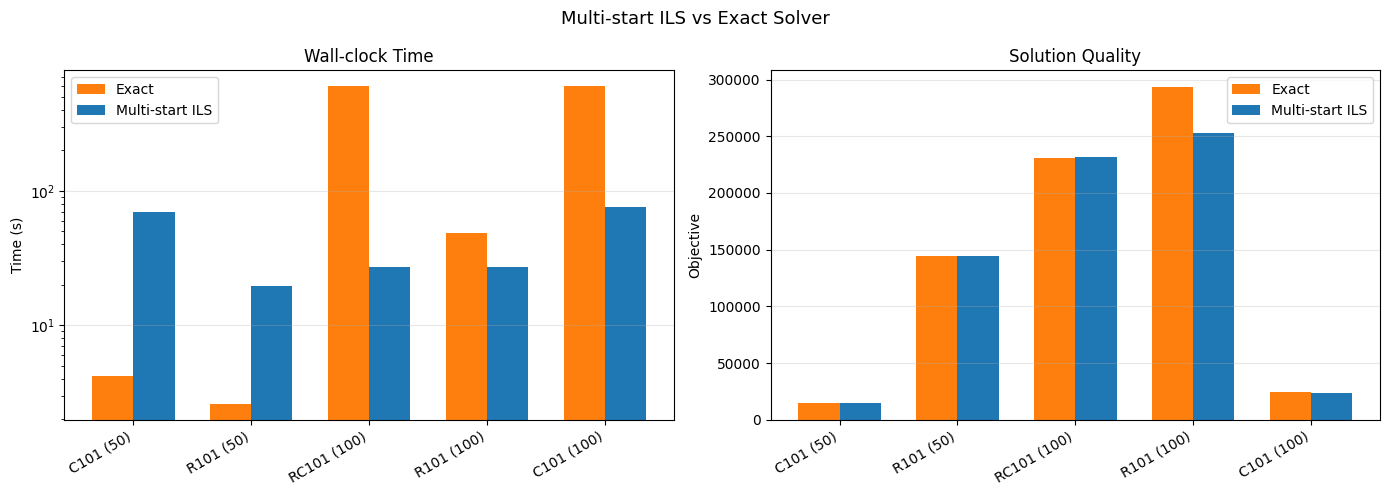

In [11]:
# Bar chart: ILS time vs Exact time, grouped by instance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

instances = df_scale["Instance"].tolist()
exact_times = [float(t) if t != "-" else 0 for t in df_scale["Exact time (s)"].tolist()]
ils_times = df_scale["ILS time (s)"].tolist()

# Time comparison
x = np.arange(len(instances))
width = 0.35
axes[0].bar(x - width/2, exact_times, width, label='Exact', color='tab:orange')
axes[0].bar(x + width/2, ils_times, width, label='Multi-start ILS', color='tab:blue')
axes[0].set_ylabel("Time (s)")
axes[0].set_title("Wall-clock Time")
axes[0].set_xticks(x)
axes[0].set_xticklabels(instances, rotation=30, ha='right')
axes[0].legend()
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3, axis='y')

# Objective comparison
exact_objs = [v if v is not None else 0 for v in df_scale["Exact obj"].tolist()]
ils_objs = [v if v is not None else 0 for v in df_scale["ILS obj"].tolist()]
axes[1].bar(x - width/2, exact_objs, width, label='Exact', color='tab:orange')
axes[1].bar(x + width/2, ils_objs, width, label='Multi-start ILS', color='tab:blue')
axes[1].set_ylabel("Objective")
axes[1].set_title("Solution Quality")
axes[1].set_xticks(x)
axes[1].set_xticklabels(instances, rotation=30, ha='right')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

fig.suptitle("Multi-start ILS vs Exact Solver", fontsize=13)
fig.tight_layout()

---
## 7. ILS Under Different Slope Regimes

Does the slope regime affect local search as much as it affects the exact solver?

**Settings:** R101 (50), $\eta = 1$, ILS 300 steps, R1 initial tour.

**Purpose:** Compare with exact solver slope results (exact.ipynb Table 2).
- **Zero slopes** should have highest objective (all info is static, purely additive) but may show less improvement from search (timing irrelevant).
- **Positive slopes** should have highest improvement from search (ILS can optimize arrival timing to maximize growth).
- **Random slopes** test the general case where the search must balance early and late arrivals.

In [12]:
ILS_STEPS_SLOPE = 10000

slope_rows = []
for ds_name, ds_path in datasets.items():
    print(f"\n{'='*60}")
    print(f"  {ds_name}")
    for slope in ['random', 'positive', 'negative', 'zero']:
        random.seed(SEED)
        instance, graph, uav = make_instance(ds_path, slope=slope)
        init_tour = build_R4(instance)
        init_state = State.initial_state(instance, init_tour)
        init_obj = init_state.value

        opt = Optimizer(proposal=lambda s: universal_proposal(s),
                        initial_state=init_state, maximize=True)
        t0 = time.time()
        for s in opt.run_ils(total_steps=ILS_STEPS_SLOPE, t_improve=30,
                             k_remove=2, tabu_tenure=10):
            pass
        elapsed = time.time() - t0
        slope_rows.append({
            "Instance": ds_name,
            "Slope": slope,
            "Init obj": round(init_obj, 2),
            "Final obj": round(opt._best_score, 2) if opt._best_score else None,
            "Time (s)": round(elapsed, 1),
            "Final tour len": len(list(opt._best_state.tour.nodes)) - 1 if opt._best_state else None,
        })

df_ils_slopes = pd.DataFrame(slope_rows)
df_ils_slopes


  C101 (50)

  R101 (50)

  RC101 (100)

  R101 (100)

  C101 (100)


,Instance,Slope,Init obj,Final obj,Time (s),Final tour len
0,C101 (50),random,3243.31,14640.66,19.1,30
1,C101 (50),positive,10310.39,25241.11,24.8,38
2,C101 (50),negative,170.00,418.44,11.2,21
3,C101 (50),zero,270.00,770.00,22.3,42
4,R101 (50),random,21328.22,123734.41,4.9,7
5,R101 (50),positive,57920.08,208935.43,5.0,8
6,R101 (50),negative,10.00,155.00,4.7,7
7,R101 (50),zero,87.00,159.00,5.2,8
8,RC101 (100),random,91649.92,222043.77,7.2,11
9,RC101 (100),positive,121975.47,303219.76,9.3,15


---
## 8. ILS Energy Sensitivity ($\eta$ sweep)

How does ILS perform under different energy budgets?

**Settings:** R101 (50), random slopes, ILS 10k steps, R4 initial tour, 3 seeds averaged per $\eta$.

**Purpose:** Compare with exact solver $\eta$ sweep (exact.ipynb Table 3).
- At tight $\eta$, the initial tour may be infeasible — falls back to shorter tours.
- Tour length should decrease as $\eta$ decreases.
- Multi-seed averaging smooths stochastic noise to reveal the true $\eta$ trend.

In [13]:
ILS_STEPS_ETA = 10000
SEEDS_ETA = [42, 123, 456]

eta_rows = []
for ds_name, ds_path in datasets.items():
    print(f"\n{'='*60}")
    print(f"  {ds_name}")
    for eta in [0.5, 0.75, 1.0, 1.25, 1.5]:
        seed_objs = []
        seed_times = []
        seed_lens = []
        init_objs = []

        for seed_val in SEEDS_ETA:
            random.seed(seed_val)
            instance, graph, uav = make_instance(ds_path, eta=eta)

            try:
                init_tour = build_R4(instance)
                solver_check = Solver(init_tour, instance)
                if solver_check.solution is None:
                    raise ValueError("R4 infeasible")
            except:
                init_tour = build_R1(instance)
                solver_check = Solver(init_tour, instance)

            if solver_check.solution is None:
                continue

            init_obj = solver_check.get_tour_data().objective
            init_objs.append(init_obj)

            state = State.initial_state(instance, init_tour)
            opt = Optimizer(proposal=lambda s: universal_proposal(s),
                            initial_state=state, maximize=True)
            t0 = time.time()
            for s in opt.run_ils(total_steps=ILS_STEPS_ETA, t_improve=30,
                                 k_remove=2, tabu_tenure=10):
                pass
            elapsed = time.time() - t0

            if opt._best_score:
                seed_objs.append(opt._best_score)
                seed_times.append(elapsed)
            if opt._best_state:
                seed_lens.append(len(list(opt._best_state.tour.nodes)) - 1)

        if seed_objs:
            eta_rows.append({
                "Instance": ds_name,
                "eta": eta,
                "Init obj (mean)": round(np.mean(init_objs), 2),
                "Final obj (mean)": round(np.mean(seed_objs), 2),
                "Final obj (std)": round(np.std(seed_objs), 2),
                "Time (s)": round(np.mean(seed_times), 1),
                "Final tour len": round(np.mean(seed_lens)),
            })
        else:
            eta_rows.append({
                "Instance": ds_name, "eta": eta, "Init obj (mean)": None,
                "Final obj (mean)": None, "Final obj (std)": None,
                "Time (s)": None, "Final tour len": None,
            })

df_ils_eta = pd.DataFrame(eta_rows)
df_ils_eta


  C101 (50)

  R101 (50)

  RC101 (100)

  R101 (100)

  C101 (100)


,Instance,eta,Init obj (mean),Final obj (mean),Final obj (std),Time (s),Final tour len
0,C101 (50),0.50,1514.66,9252.08,121.95,13.1,17
1,C101 (50),0.75,7187.34,13311.86,255.21,15.8,24
2,C101 (50),1.00,3243.31,14603.96,57.38,17.3,31
3,C101 (50),1.25,4519.94,14623.87,43.36,17.3,33
4,C101 (50),1.50,3611.41,14661.61,9.42,16.8,32
5,R101 (50),0.50,36482.91,44546.68,372.08,4.5,4
6,R101 (50),0.75,36522.91,81062.00,8274.56,5.1,6
7,R101 (50),1.00,21328.22,130927.53,5086.31,4.7,6
8,R101 (50),1.25,38220.34,131945.06,3993.68,5.0,6
9,R101 (50),1.50,21579.93,135099.51,467.39,4.5,6


---
## 9. Multi-Start ILS

Run ILS from all 6 initial tours and keep the global best.
This is the recommended production configuration.

**Settings:** $\eta = 1$, random slopes, 200 ILS steps per start, 5 starts (R1–R5).

**Purpose:** This is the full multi-start ILS.
- "Best start" shows which initial tour led to the global best — if R4 consistently wins, it validates the information-efficiency heuristic.
- Total time = sum of all 5 ILS runs. Compare with exact solver time from Table 7.
- On 100-node instances, multi-start ILS should be faster than exact and potentially find better incumbents.

In [14]:
ILS_STEPS_MS = 10000  # per start

ms_rows = []
for ds_name, path in datasets.items():
    instance, graph, uav = make_instance(path)
    best_obj_global = -float('inf')
    best_tour_name = None
    total_time = 0

    per_start = []
    for h_name, builder in INITIAL_TOURS.items():
        tour_graph = builder(instance)
        solver_check = Solver(tour_graph, instance)
        if solver_check.solution is None:
            per_start.append({"start": h_name, "obj": None})
            continue

        state = State.initial_state(instance, tour_graph)
        opt = Optimizer(proposal=lambda s: universal_proposal(s),
                        initial_state=state, maximize=True)
        t0 = time.time()
        for s in opt.run_ils(total_steps=ILS_STEPS_MS, t_improve=30,
                             k_remove=2, tabu_tenure=10):
            pass
        elapsed = time.time() - t0
        total_time += elapsed
        per_start.append({"start": h_name, "obj": opt._best_score})

        if opt._best_score and opt._best_score > best_obj_global:
            best_obj_global = opt._best_score
            best_tour_name = h_name

    ms_rows.append({
        "Instance": ds_name,
        "n": len(graph.nodes),
        "Best obj": round(best_obj_global, 2) if best_obj_global > -float('inf') else None,
        "Best start": best_tour_name,
        "Total time (s)": round(total_time, 1),
    })

df_ms = pd.DataFrame(ms_rows)
df_ms

,Instance,n,Best obj,Best start,Total time (s)
0,C101 (50),51,14638.69,R3 (random),80.8
1,R101 (50),51,144232.37,R4 (info-eff),19.7
2,RC101 (100),101,223148.40,R1 (earliest),31.6
3,R101 (100),101,289604.57,R2 (rand+earliest),28.8
4,C101 (100),101,23485.70,R4 (info-eff),78.9


---
## 10. Reproducibility

5 runs with different random seeds to check variance in ILS results.

**Settings:** R101 (50), $\eta = 1$, random slopes, ILS 10k steps.

**Purpose:** Quantify stochastic variance in ILS.
- **R4 start** (deterministic): isolates search variance only — all runs start from the same tour.
- **R2 start** (stochastic): shows total variance from both initialization and search.
- Small std → ILS is reliable, single runs are representative.
- Large std → multi-start is essential, results should be reported as mean ± std.

In [15]:
ILS_STEPS_REPRO = 10000
seeds = [42, 123, 456, 789, 1024]

all_repro = []
for ds_name, ds_path in datasets.items():
    print(f"\n{'='*60}")
    print(f"  {ds_name}")
    instance, graph, uav = make_instance(ds_path)

    # --- R4 start (deterministic) — isolates search variance ---
    init_tour_r4 = build_R4(instance)
    for seed_val in seeds:
        random.seed(seed_val)
        state = State.initial_state(instance, init_tour_r4)
        opt = Optimizer(proposal=lambda s: universal_proposal(s),
                        initial_state=state, maximize=True)
        t0 = time.time()
        for s in opt.run_ils(total_steps=ILS_STEPS_REPRO, t_improve=30,
                             k_remove=2, tabu_tenure=10):
            pass
        elapsed = time.time() - t0
        all_repro.append({
            "Instance": ds_name, "Start": "R4", "Seed": seed_val,
            "Best obj": round(opt._best_score, 2) if opt._best_score else None,
            "Time (s)": round(elapsed, 1),
            "Tour len": len(list(opt._best_state.tour.nodes)) - 1 if opt._best_state else None,
        })

    # --- R2 start (stochastic) — total variance ---
    for seed_val in seeds:
        rng = random.Random(seed_val)
        random.seed(seed_val)
        init_tour = build_R2(instance, rng=rng)
        state = State.initial_state(instance, init_tour)
        opt = Optimizer(proposal=lambda s: universal_proposal(s),
                        initial_state=state, maximize=True)
        t0 = time.time()
        for s in opt.run_ils(total_steps=ILS_STEPS_REPRO, t_improve=30,
                             k_remove=2, tabu_tenure=10):
            pass
        elapsed = time.time() - t0
        all_repro.append({
            "Instance": ds_name, "Start": "R2", "Seed": seed_val,
            "Best obj": round(opt._best_score, 2) if opt._best_score else None,
            "Time (s)": round(elapsed, 1),
            "Tour len": len(list(opt._best_state.tour.nodes)) - 1 if opt._best_state else None,
        })

df_repro = pd.DataFrame(all_repro)
print(df_repro.to_string(index=False))

# Summary stats per dataset × start type
for ds_name in datasets:
    for start in ["R4", "R2"]:
        objs = df_repro[(df_repro["Instance"] == ds_name) & (df_repro["Start"] == start)]["Best obj"].dropna()
        if len(objs) > 0:
            print(f"\n{ds_name} / {start}: mean={objs.mean():.2f}, std={objs.std():.2f}, CV={objs.std()/objs.mean()*100:.1f}%")


  C101 (50)

  R101 (50)

  RC101 (100)

  R101 (100)

  C101 (100)
   Instance Start  Seed  Best obj  Time (s)  Tour len
  C101 (50)    R4    42  14640.66      19.4        30
  C101 (50)    R4   123  14648.29      16.5        32
  C101 (50)    R4   456  14522.94      17.2        31
  C101 (50)    R4   789  14429.45      19.1        36
  C101 (50)    R4  1024  14524.07      18.3        34
  C101 (50)    R2    42  14502.30      18.4        34
  C101 (50)    R2   123  14647.73      18.6        33
  C101 (50)    R2   456  14488.77      16.6        32
  C101 (50)    R2   789  14142.04      17.7        31
  C101 (50)    R2  1024  14578.21      15.7        28
  R101 (50)    R4    42 123734.41       5.0         7
  R101 (50)    R4   123 134524.09       4.5         6
  R101 (50)    R4   456 134524.09       4.8         6
  R101 (50)    R4   789 134524.09       4.5         6
  R101 (50)    R4  1024 141444.65       4.8         7
  R101 (50)    R2    42  78584.70       6.9         9
  R101 (50)  

---
## 11. Scalability: 200-Node Instances (Gehring & Homberger)

ILS on 200-customer Gehring & Homberger benchmark instances (extended Solomon format).

**Settings:** $\eta = 1$, random slopes, ILS 10k steps, R4 initial tour.

**Purpose:** Test scalability of ILS beyond 100-node Solomon instances.
- C1_2_1: clustered customers, narrow time windows (200 nodes)
- R1_2_1: random customers, narrow time windows (200 nodes)
- RC1_2_1: mixed random+clustered, narrow time windows (200 nodes)

In [16]:
ILS_STEPS_200 = 10000

datasets_200 = {
    "C1_2_1 (200)":  "datasets/homberger_200/c1_2_1.txt",
    "R1_2_1 (200)":  "datasets/homberger_200/r1_2_1.txt",
    "RC1_2_1 (200)": "datasets/homberger_200/rc1_2_1.txt",
}

rows_200 = []
for ds_name, path in datasets_200.items():
    print(f"\n{'='*60}")
    print(f"  {ds_name}")
    print(f"{'='*60}")
    instance, graph, uav = make_instance(path)
    n = len(graph.nodes)
    print(f"  Nodes: {n}")

    best_obj_global = -float('inf')
    best_start = None
    best_tour_len = None
    total_time = 0
    init_obj_best = None

    for h_name, builder in INITIAL_TOURS.items():
        try:
            tour_graph = builder(instance)
            solver_check = Solver(tour_graph, instance)
            if solver_check.solution is None:
                print(f"    {h_name}: infeasible")
                continue
        except Exception as e:
            print(f"    {h_name}: failed ({e})")
            continue

        init_obj = solver_check.get_tour_data().objective
        init_len = len(list(tour_graph.nodes)) - 1
        print(f"    {h_name}: init len={init_len}, obj={init_obj:.2f}")

        # Run ILS
        state = State.initial_state(instance, tour_graph)
        opt = Optimizer(proposal=lambda s: universal_proposal(s),
                        initial_state=state, maximize=True)
        t0 = time.time()
        for s in opt.run_ils(total_steps=ILS_STEPS_200, t_improve=30,
                             k_remove=2, tabu_tenure=10):
            pass
        elapsed = time.time() - t0
        total_time += elapsed

        final_obj = opt._best_score
        final_len = len(list(opt._best_state.tour.nodes)) - 1 if opt._best_state else None
        print(f"      -> final obj={final_obj:.2f}, time={elapsed:.1f}s, tour_len={final_len}")

        if final_obj > best_obj_global:
            best_obj_global = final_obj
            best_start = h_name
            best_tour_len = final_len
            init_obj_best = init_obj

    improvement = ((best_obj_global - init_obj_best) / abs(init_obj_best) * 100) if init_obj_best else None
    rows_200.append({
        "Instance": ds_name,
        "n": n,
        "Best start": best_start,
        "Best obj": round(best_obj_global, 2) if best_obj_global > -float('inf') else None,
        "Improvement (%)": round(improvement, 1) if improvement is not None else None,
        "Total time (s)": round(total_time, 1),
        "Tour len": best_tour_len,
    })

df_200 = pd.DataFrame(rows_200)
df_200


  C1_2_1 (200)
  Nodes: 201
    R1 (earliest): init len=4, obj=268.84
      -> final obj=13268.42, time=14.3s, tour_len=27
    R2 (rand+earliest): init len=4, obj=5.37
      -> final obj=15681.88, time=12.3s, tour_len=25
    R3 (random): init len=4, obj=885.53
      -> final obj=14113.86, time=13.1s, tour_len=26
    R4 (info-eff): init len=18, obj=4492.14
      -> final obj=12024.50, time=15.6s, tour_len=26

  R1_2_1 (200)
  Nodes: 201
    R1 (earliest): init len=4, obj=-794.36
      -> final obj=37112.45, time=8.3s, tour_len=18
    R2 (rand+earliest): init len=4, obj=5805.85
      -> final obj=40759.93, time=7.0s, tour_len=18
    R3 (random): init len=4, obj=2583.30
      -> final obj=42191.37, time=8.5s, tour_len=20
    R4 (info-eff): init len=13, obj=16467.76
      -> final obj=47064.25, time=9.7s, tour_len=19

  RC1_2_1 (200)
  Nodes: 201
    R1 (earliest): init len=4, obj=1020.96
      -> final obj=50015.67, time=16.3s, tour_len=16
    R2 (rand+earliest): init len=4, obj=-1045.12

,Instance,n,Best start,Best obj,Improvement (%),Total time (s),Tour len
0,C1_2_1 (200),201,R2 (rand+earliest),15681.88,291693.9,55.3,25
1,R1_2_1 (200),201,R4 (info-eff),47064.25,185.8,33.4,19
2,RC1_2_1 (200),201,R2 (rand+earliest),63502.46,6176.1,50.7,22


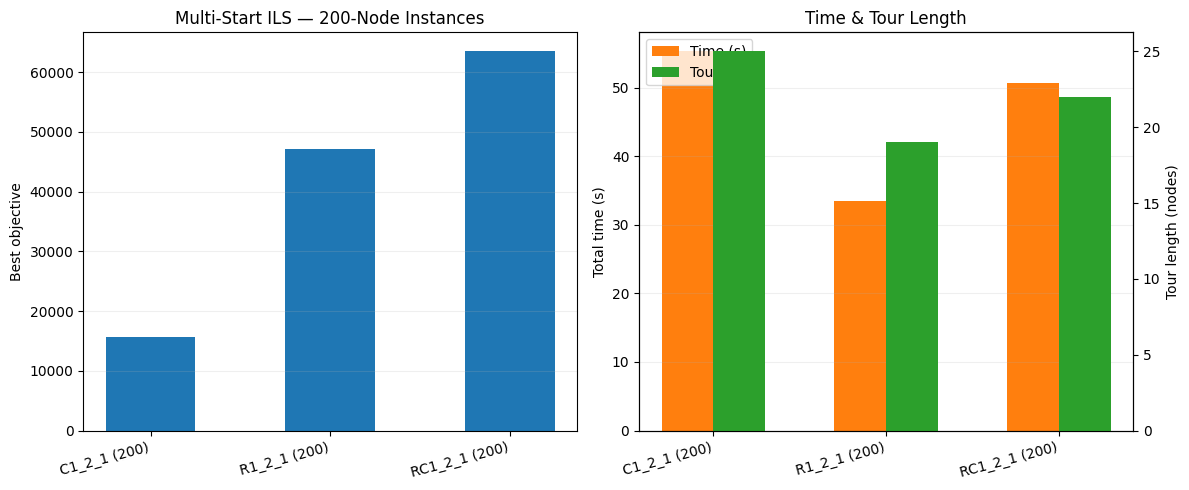

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

instances = df_200["Instance"].tolist()
x = np.arange(len(instances))

# Plot 1: Objective values
axes[0].bar(x, df_200["Best obj"], color='tab:blue', width=0.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(instances, rotation=15, ha='right')
axes[0].set_ylabel("Best objective")
axes[0].set_title("Multi-Start ILS — 200-Node Instances")
axes[0].grid(True, alpha=0.2, axis='y')

# Plot 2: Time and tour length
ax2 = axes[1]
bars = ax2.bar(x - 0.15, df_200["Total time (s)"], width=0.3, color='tab:orange', label='Time (s)')
ax2.set_ylabel("Total time (s)")
ax2.set_xticks(x)
ax2.set_xticklabels(instances, rotation=15, ha='right')
ax2.set_title("Time & Tour Length")
ax2.grid(True, alpha=0.2, axis='y')

ax3 = ax2.twinx()
ax3.bar(x + 0.15, df_200["Tour len"], width=0.3, color='tab:green', label='Tour len')
ax3.set_ylabel("Tour length (nodes)")

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax3.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

fig.tight_layout()

---
## 12. Energy Sensitivity on 200-Node Instances ($\eta$ sweep)

How does the energy budget affect ILS performance on large instances?

**Settings:** 3 Gehring & Homberger 200-node instances, random slopes, ILS 10k steps,
multi-start (all 4 initial tours), $\eta \in \{0.5, 0.75, 1.0, 1.25, 1.5\}$.

**Purpose:** Extend the $\eta$ sensitivity analysis (Section 8) to 200-node instances.
- At tight $\eta$, fewer nodes can be visited and objective drops.
- At loose $\eta$, energy is no longer the binding constraint — time windows dominate.
- Multi-start ILS keeps the global best across all 4 initial tours per $(\text{instance}, \eta)$ pair.

In [19]:
ILS_STEPS_ETA200 = 10000
ETA_VALUES_200 = [0.5, 0.75, 1.0, 1.25, 1.5]

datasets_200_eta = {
    "C1_2_1 (200)":  "datasets/homberger_200/c1_2_1.txt",
    "R1_2_1 (200)":  "datasets/homberger_200/r1_2_1.txt",
    "RC1_2_1 (200)": "datasets/homberger_200/rc1_2_1.txt",
}

eta200_rows = []
for ds_name, path in datasets_200_eta.items():
    print(f"\n{'='*60}")
    print(f"  {ds_name}")
    print(f"{'='*60}")

    for eta in ETA_VALUES_200:
        print(f"\n  eta = {eta}")
        instance, graph, uav = make_instance(path, eta=eta)
        n = len(graph.nodes)

        best_obj_global = -float('inf')
        best_start = None
        best_tour_len = None
        total_time = 0
        init_obj_best = None

        for h_name, builder in INITIAL_TOURS.items():
            try:
                tour_graph = builder(instance)
                solver_check = Solver(tour_graph, instance)
                if solver_check.solution is None:
                    print(f"    {h_name}: infeasible")
                    continue
            except Exception as e:
                print(f"    {h_name}: failed ({e})")
                continue

            init_obj = solver_check.get_tour_data().objective
            init_len = len(list(tour_graph.nodes)) - 1
            print(f"    {h_name}: init len={init_len}, obj={init_obj:.2f}")

            state = State.initial_state(instance, tour_graph)
            opt = Optimizer(proposal=lambda s: universal_proposal(s),
                            initial_state=state, maximize=True)
            t0 = time.time()
            for s in opt.run_ils(total_steps=ILS_STEPS_ETA200, t_improve=30,
                                 k_remove=2, tabu_tenure=10):
                pass
            elapsed = time.time() - t0
            total_time += elapsed

            final_obj = opt._best_score
            final_len = len(list(opt._best_state.tour.nodes)) - 1 if opt._best_state else None
            print(f"      -> final obj={final_obj:.2f}, time={elapsed:.1f}s, tour_len={final_len}")

            if final_obj > best_obj_global:
                best_obj_global = final_obj
                best_start = h_name
                best_tour_len = final_len
                init_obj_best = init_obj

        improvement = ((best_obj_global - init_obj_best) / abs(init_obj_best) * 100
                       ) if init_obj_best and init_obj_best != 0 else None
        eta200_rows.append({
            "Instance": ds_name,
            "n": n,
            "eta": eta,
            "Best start": best_start,
            "Best obj": round(best_obj_global, 2) if best_obj_global > -float('inf') else None,
            "Improvement (%)": round(improvement, 1) if improvement is not None else None,
            "Total time (s)": round(total_time, 1),
            "Tour len": best_tour_len,
        })

df_eta200 = pd.DataFrame(eta200_rows)
df_eta200


  C1_2_1 (200)

  eta = 0.5
    R1 (earliest): init len=4, obj=268.84
      -> final obj=7789.08, time=9.1s, tour_len=12
    R2 (rand+earliest): init len=1, obj=111.24
      -> final obj=8291.58, time=9.7s, tour_len=13
    R3 (random): init len=1, obj=111.24
      -> final obj=9771.97, time=8.7s, tour_len=15
    R4 (info-eff): init len=10, obj=289.14
      -> final obj=6835.36, time=11.4s, tour_len=16

  eta = 0.75
    R1 (earliest): init len=4, obj=268.84
      -> final obj=11306.55, time=12.3s, tour_len=24
    R2 (rand+earliest): init len=4, obj=5.37
      -> final obj=11861.83, time=10.9s, tour_len=20
    R3 (random): init len=4, obj=885.53
      -> final obj=11721.39, time=10.7s, tour_len=19
    R4 (info-eff): init len=21, obj=4008.56
      -> final obj=9719.12, time=16.2s, tour_len=28

  eta = 1.0
    R1 (earliest): init len=4, obj=268.84
      -> final obj=14642.09, time=12.2s, tour_len=25
    R2 (rand+earliest): init len=4, obj=5.37
      -> final obj=13642.23, time=11.4s, tour

,Instance,n,eta,Best start,Best obj,Improvement (%),Total time (s),Tour len
0,C1_2_1 (200),201,0.50,R3 (random),9771.97,8684.8,38.9,15
1,C1_2_1 (200),201,0.75,R2 (rand+earliest),11861.83,220614.2,50.1,20
2,C1_2_1 (200),201,1.00,R1 (earliest),14642.09,5346.3,52.8,25
3,C1_2_1 (200),201,1.25,R2 (rand+earliest),14979.45,278623.7,49.5,25
4,C1_2_1 (200),201,1.50,R3 (random),15982.00,1704.8,59.3,28
5,R1_2_1 (200),201,0.50,R1 (earliest),32540.32,4196.4,45.0,9
6,R1_2_1 (200),201,0.75,R2 (rand+earliest),36587.05,530.2,54.2,12
7,R1_2_1 (200),201,1.00,R3 (random),52407.07,1928.7,112.0,16
8,R1_2_1 (200),201,1.25,R4 (info-eff),55004.53,358.6,80.9,18
9,R1_2_1 (200),201,1.50,R2 (rand+earliest),47965.77,726.2,69.1,18


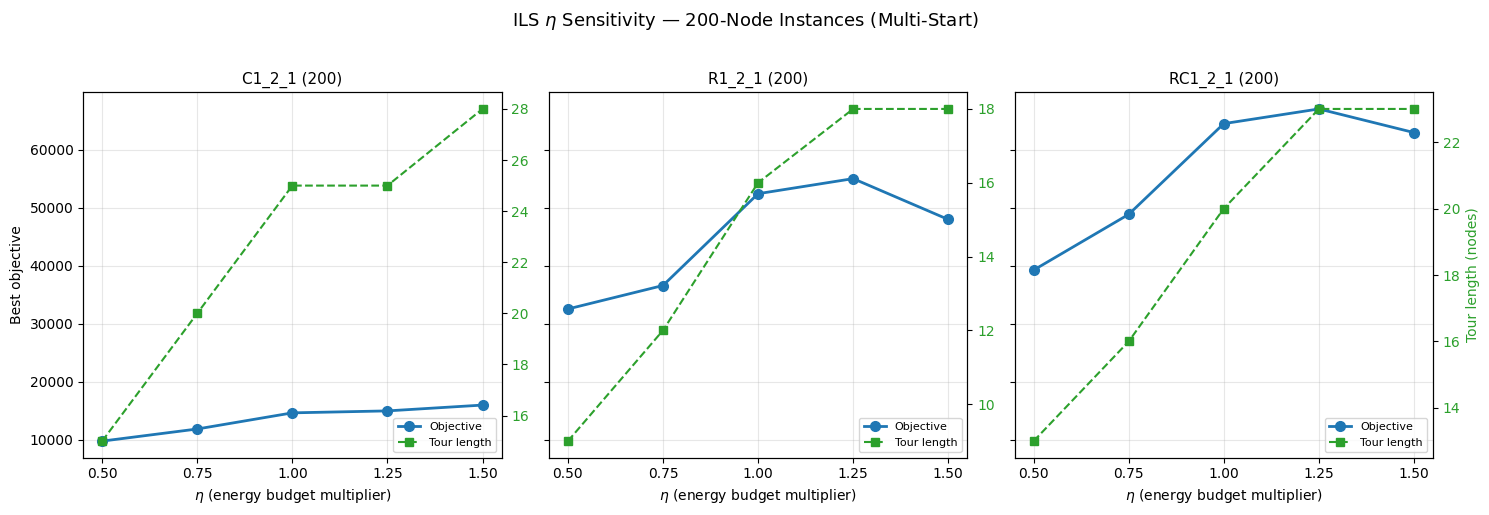

In [20]:
instances_200 = list(datasets_200_eta.keys())
n_inst = len(instances_200)
fig, axes = plt.subplots(1, n_inst, figsize=(5 * n_inst, 5), sharey=True)
if n_inst == 1:
    axes = [axes]

for ax, inst_name in zip(axes, instances_200):
    sub = df_eta200[df_eta200['Instance'] == inst_name]
    ax.plot(sub['eta'], sub['Best obj'], 'o-', color='tab:blue',
            linewidth=2, markersize=7, label='Objective')
    ax.set_xlabel(r'$\eta$ (energy budget multiplier)')
    ax.set_title(inst_name, fontsize=11)
    ax.set_xticks(ETA_VALUES_200)
    ax.grid(True, alpha=0.3)

    # Tour length on secondary axis
    ax2 = ax.twinx()
    ax2.plot(sub['eta'], sub['Tour len'], 's--', color='tab:green',
             linewidth=1.5, markersize=6, label='Tour length')
    if inst_name == instances_200[-1]:
        ax2.set_ylabel('Tour length (nodes)', color='tab:green')
    ax2.tick_params(axis='y', labelcolor='tab:green')

    # Combined legend
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=8)

axes[0].set_ylabel('Best objective')
fig.suptitle(r'ILS $\eta$ Sensitivity — 200-Node Instances (Multi-Start)', fontsize=13, y=1.02)
fig.tight_layout()